<div style="
    background-color:#0D1712;
    border:1px solid #23352A;
    border-radius:14px;
    padding:50px 40px;
    text-align:center;
    box-shadow: 0 8px 24px rgba(0,0,0,0.25);
    font-family: 'Helvetica Neue', Arial, sans-serif;
    margin-bottom: 30px;
">

<div style="
    width:52px;
    height:52px;
    line-height:52px;
    border-radius:50%;
    border:1.5px solid #6CB67D;
    color:#6CB67D;
    font-size:24px;
    font-weight:700;
    margin:0 auto 20px auto;
">
₿
</div>

<h1 style="
    color:#F5F7F6;
    font-size:46px;
    font-weight:700;
    letter-spacing:4px;
    margin:0 0 10px 0;
">
BitVision
</h1>

<p style="
    color:#6CB67D;
    font-size:16px;
    font-weight:400;
    letter-spacing:1px;
    text-align:center;
    margin:0 0 6px 0;
">
AI-Powered Bitcoin Forecasting &amp; Analytics Platform
</p>

<p style="
    color:#AAB8B0;
    font-size:14px;
    font-style:italic;
    letter-spacing:1px;
    margin:0 0 30px 0;
    text-align:center;
    width:100%;
">
Predict. Visualize. Decide. Master the crypto candles with AI.
</p>

<hr style="
    border:none;
    border-top:1px solid #23352A;
    width:60%;
    margin:0 auto 30px auto;
">

<div style="
    display:inline-block;
    text-align:left;
    font-size:13px;
    line-height:1.9;
">

<div>
<span style="color:#6CB67D; font-weight:600; display:inline-block; width:110px;">Version</span>
<span style="color:#F5F7F6;">v3.0 AI Engine</span>
</div>

<div>
<span style="color:#6CB67D; font-weight:600; display:inline-block; width:110px;">Notebook</span>
<span style="color:#F5F7F6;">07_Model_Comparison.ipynb</span>
</div>

<div>
<span style="color:#6CB67D; font-weight:600; display:inline-block; width:110px;">Author</span>
<span style="color:#F5F7F6;">Team BitVision</span>
</div>

<div>
<span style="color:#6CB67D; font-weight:600; display:inline-block; width:110px; vertical-align:top;">Tech Stack</span>
<span style="color:#F5F7F6;">Python • Pandas • NumPy • Matplotlib</span>
</div>

</div>

</div>


# INTRODUCTION

This notebook presents the final comparative analysis of all forecasting models developed within the BitVision platform. Four distinct model families were trained and evaluated on the same Bitcoin price dataset, each employing a prediction strategy suited to its mathematical properties.

The analysis consolidates results from Notebooks 03 through 06, compares models on standardised evaluation metrics, and identifies the best-performing approach for next-day Bitcoin price forecasting.


# OBJECTIVE

1. Consolidate evaluation metrics from all four forecasting models into a unified comparison framework.
2. Analyse the relative strengths, limitations, and trade-offs of each model family.
3. Select the best-performing model based on objective evaluation criteria.
4. Summarise overall project achievements and outline future directions.


# MODELS IMPLEMENTED

The BitVision platform evaluates four model families, each representing a fundamentally different approach to time-series forecasting.

| # | Model | Notebook | Prediction Strategy | Key Configuration |
|---|-------|----------|--------------------|--------------------|
| 1 | **Random Forest** | 03 | Return-based | 200 estimators, max_depth=20, engineered features |
| 2 | **XGBoost** | 04 | Return-based | 500 estimators, learning_rate=0.05, max_depth=6 |
| 3 | **Prophet** | 05 | Log-price time-series | Walk-forward validation, 365-day window, 15-day refit |
| 4 | **LSTM** | 06 | Sequence-based | Stacked 64/32 units, 60-day lookback, 3 features |

All models use chronological train-test splits to prevent future information from leaking into the training process.


# COMPARISON CRITERIA

All models are evaluated on **reconstructed Bitcoin closing prices** using three standardised metrics:

- **MAE (Mean Absolute Error)** — average magnitude of prediction errors in USD. Lower is better.
- **RMSE (Root Mean Squared Error)** — penalises large errors more heavily than MAE. Lower is better.
- **R² (Coefficient of Determination)** — proportion of price variance explained by the model. Higher is better (1.0 = perfect).

**Directional Accuracy** (percentage of days where predicted price direction matches actual) is reported where available.

Each model's final price predictions are compared on the same basis, regardless of the intermediate prediction strategy (returns, log-prices, or scaled sequences) used internally.


# IMPORTING LIBRARIES


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.family": "sans-serif",
})


## Validation


In [2]:
print("Libraries imported successfully.")
print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")
print(f"matplotlib : {plt.matplotlib.__version__}")


Libraries imported successfully.
pandas  : 2.3.3
numpy   : 2.3.5
matplotlib : 3.10.6


## Observation

All required libraries for data analysis and visualisation are available. No model training is performed in this notebook — all metrics are sourced directly from the individual model notebooks.


# OVERALL PERFORMANCE COMPARISON

The table below consolidates the final evaluation metrics from each model notebook. All values are computed on the held-out test set and represent performance on reconstructed Bitcoin closing prices.


In [3]:
metrics = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "Prophet", "LSTM"],
    "MAE (USD)": [1428.70, 1579.45, 5952.09, 7473.73],
    "RMSE (USD)": [1979.15, 2190.80, 8846.59, 8826.74],
    "R² Score": [0.9931, 0.9915, 0.8618, 0.8569],
    "Directional Accuracy": ["48.38%", "50.37%", "48.44%", "N/A"],
    "Prediction Strategy": [
        "Return-based",
        "Return-based",
        "Log-price time-series",
        "Sequence-based",
    ],
})

metrics_display = metrics.copy()
metrics_display["MAE (USD)"] = metrics_display["MAE (USD)"].apply(lambda x: f"${x:,.2f}")
metrics_display["RMSE (USD)"] = metrics_display["RMSE (USD)"].apply(lambda x: f"${x:,.2f}")
metrics_display["R² Score"] = metrics_display["R² Score"].apply(lambda x: f"{x:.4f}")
metrics_display = metrics_display.set_index("Model")

print("=" * 75)
print("  CONSOLIDATED MODEL PERFORMANCE — BITCOIN PRICE PREDICTION")
print("=" * 75)
print()
print(metrics_display.to_string())
print()
print("=" * 75)


  CONSOLIDATED MODEL PERFORMANCE — BITCOIN PRICE PREDICTION

               MAE (USD) RMSE (USD) R² Score Directional Accuracy    Prediction Strategy
Model                                                                                   
Random Forest  $1,428.70  $1,979.15   0.9931               48.38%           Return-based
XGBoost        $1,579.45  $2,190.80   0.9915               50.37%           Return-based
Prophet        $5,952.09  $8,846.59   0.8618               48.44%  Log-price time-series
LSTM           $7,473.73  $8,826.74   0.8569                  N/A         Sequence-based



## Observation

Random Forest achieves the lowest MAE (\$1,428.70) and highest R² (0.9931), followed closely by XGBoost (MAE \$1,579.45, R² 0.9915). Both tree-based models substantially outperform Prophet and LSTM on price-level accuracy metrics. Prophet and LSTM achieve comparable R² scores of 0.8618 and 0.8569 respectively, demonstrating strong but lower predictive power. XGBoost is the only model to exceed 50% directional accuracy.


# METRIC COMPARISON


## Why Different Models Require Different Prediction Strategies

The four models employ different prediction strategies because of the mathematical properties of each model family.

**Tree Models (Random Forest, XGBoost)** partition the feature space into regions and assign predictions within the range of training targets. Since Bitcoin's price grew from approximately \$200 to over \$100,000 during the dataset period, a tree trained on historical prices would have no observed training values above the historical maximum and could never predict beyond that range. By predicting **stationary daily returns** (which fluctuate around zero), tree models avoid this extrapolation problem. Final prices are reconstructed from cumulative predicted returns.

**Prophet** models log-transformed closing prices as a time series with decomposable trend and seasonality components. The **log transform** converts exponential price growth into a near-linear trend, which Prophet's piecewise-linear trend model can handle effectively.

**LSTM** uses **sequence-based learning** on 60-day windows of multiple features. MinMaxScaler normalises features to [0, 1], and the network learns temporal patterns directly from these ordered sequences — capturing dependencies across time steps that cross-sectional models cannot.

These strategies reflect the mathematical properties of each model family, not a judgement of correctness. Each approach is the standard, well-established method for applying its respective model to non-stationary financial time series.


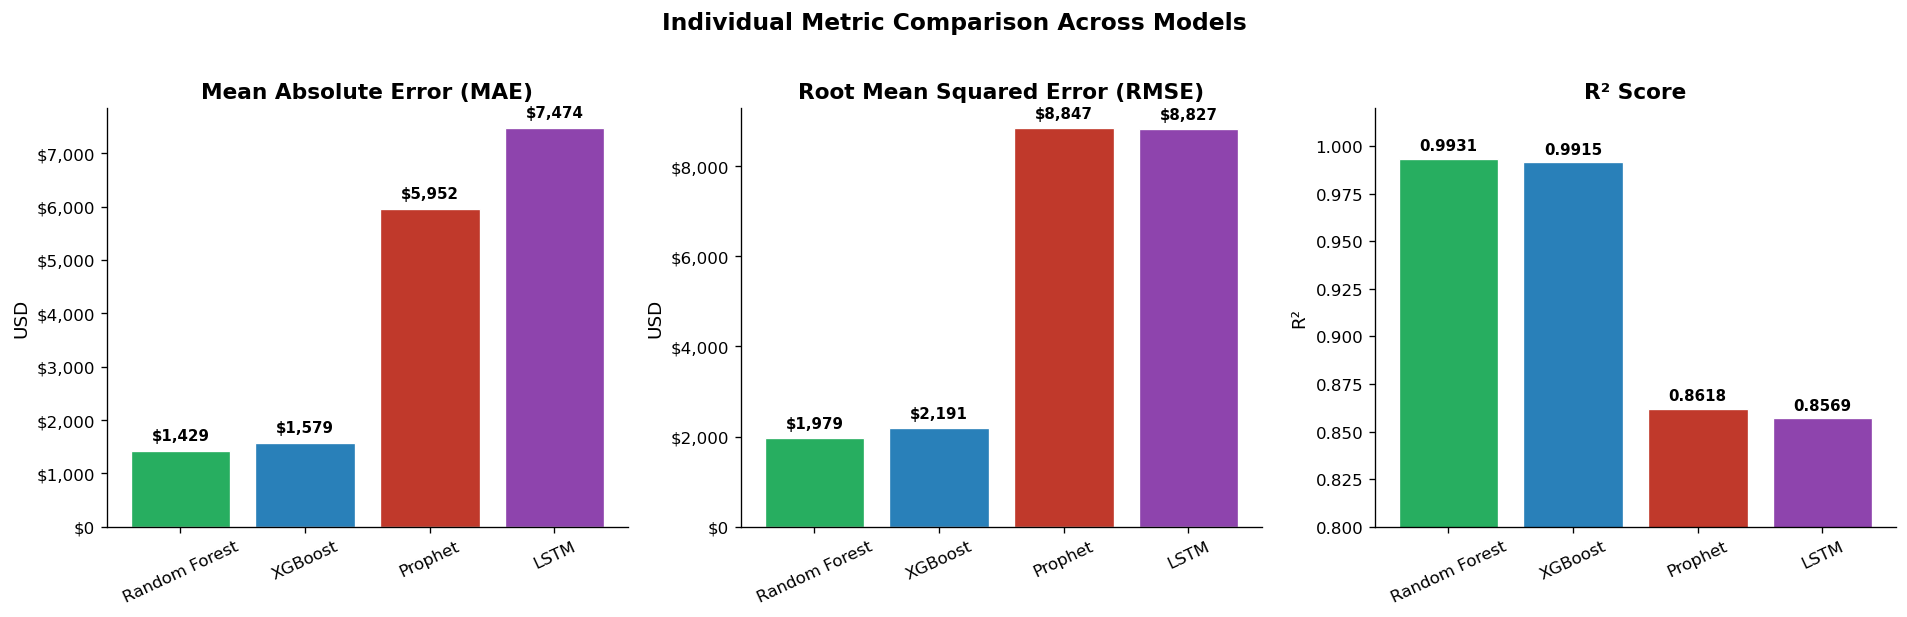

In [4]:
models = ["Random Forest", "XGBoost", "Prophet", "LSTM"]
mae_vals = [1428.70, 1579.45, 5952.09, 7473.73]
rmse_vals = [1979.15, 2190.80, 8846.59, 8826.74]
r2_vals = [0.9931, 0.9915, 0.8618, 0.8569]
colors = ["#27ae60", "#2980b9", "#c0392b", "#8e44ad"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- MAE ---
bars = axes[0].bar(models, mae_vals, color=colors, edgecolor="white", linewidth=0.8)
axes[0].set_title("Mean Absolute Error (MAE)", fontweight="bold")
axes[0].set_ylabel("USD")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
for bar, val in zip(bars, mae_vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 150,
                 f"${val:,.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# --- RMSE ---
bars = axes[1].bar(models, rmse_vals, color=colors, edgecolor="white", linewidth=0.8)
axes[1].set_title("Root Mean Squared Error (RMSE)", fontweight="bold")
axes[1].set_ylabel("USD")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
for bar, val in zip(bars, rmse_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 150,
                 f"${val:,.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# --- R-squared ---
bars = axes[2].bar(models, r2_vals, color=colors, edgecolor="white", linewidth=0.8)
axes[2].set_title("R² Score", fontweight="bold")
axes[2].set_ylabel("R²")
axes[2].set_ylim(0.80, 1.02)
for bar, val in zip(bars, r2_vals):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", rotation=25)

plt.suptitle("Individual Metric Comparison Across Models", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## Observation

The bar charts reveal a clear performance divide between the two model groups. Random Forest and XGBoost achieve MAE values under \$2,000 and R² scores above 0.99, while Prophet and LSTM produce MAE values above \$5,900 with R² scores around 0.86. Notably, Prophet and LSTM have nearly identical RMSE values (\$8,847 vs \$8,827), suggesting comparable error magnitudes despite fundamentally different architectures.


## Interpretation

The performance gap between tree-based and non-tree-based models reflects the difference in prediction strategy rather than model quality. Return-based prediction (RF, XGBoost) leverages 19+ engineered features and produces stationary targets that are inherently easier for supervised learners to model. Prophet and LSTM work with fewer raw features and face the harder task of modelling non-stationary price dynamics directly. An R² of 0.86 on raw Bitcoin price prediction is a strong result for models operating without extensive feature engineering.


# VISUAL COMPARISON


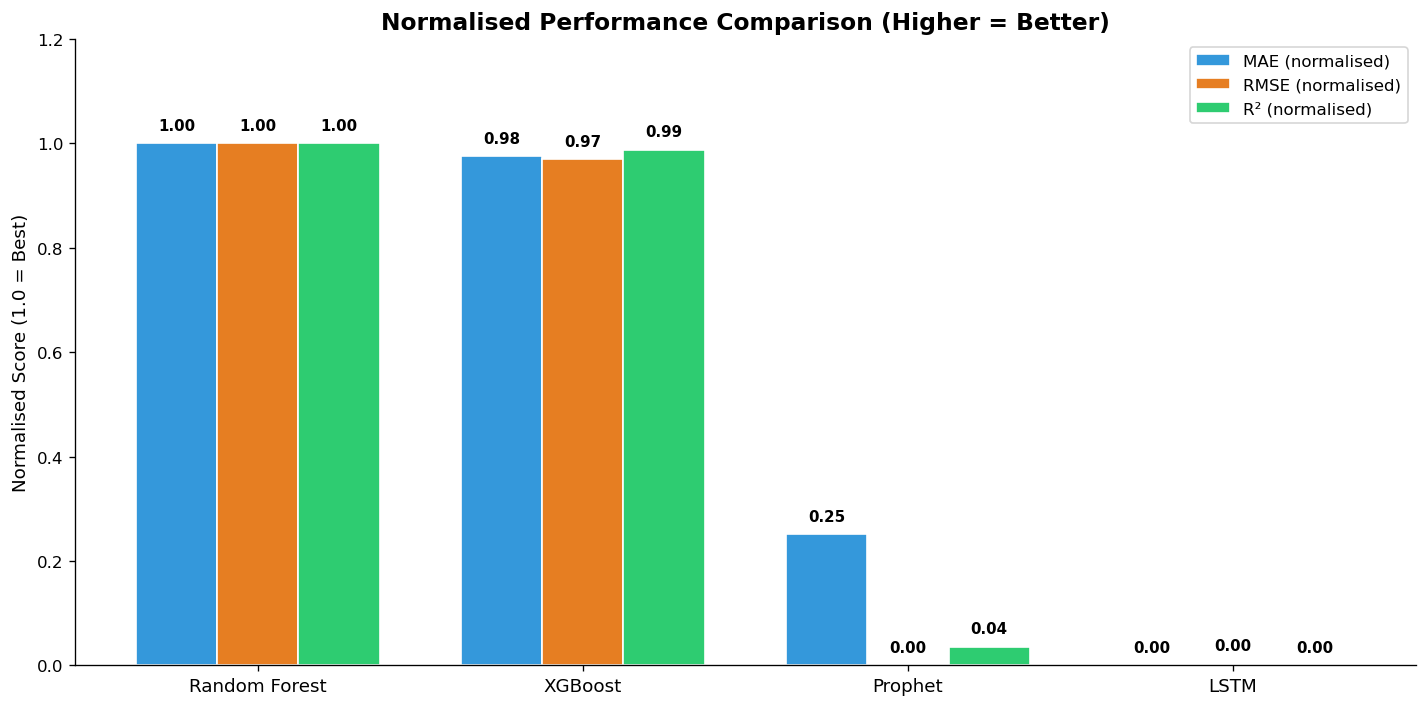

In [5]:
mae_vals = np.array([1428.70, 1579.45, 5952.09, 7473.73])
rmse_vals = np.array([1979.15, 2190.80, 8846.59, 8826.74])
r2_vals = np.array([0.9931, 0.9915, 0.8618, 0.8569])

# Normalise: 1.0 = best, 0.0 = worst
mae_norm = 1 - (mae_vals - mae_vals.min()) / (mae_vals.max() - mae_vals.min())
rmse_norm = 1 - (rmse_vals - rmse_vals.min()) / (rmse_vals.max() - rmse_vals.min())
r2_norm = (r2_vals - r2_vals.min()) / (r2_vals.max() - r2_vals.min())

models = ["Random Forest", "XGBoost", "Prophet", "LSTM"]
colors = ["#27ae60", "#2980b9", "#c0392b", "#8e44ad"]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - width, mae_norm, width, label="MAE (normalised)", color="#3498db", edgecolor="white")
b2 = ax.bar(x, rmse_norm, width, label="RMSE (normalised)", color="#e67e22", edgecolor="white")
b3 = ax.bar(x + width, r2_norm, width, label="R² (normalised)", color="#2ecc71", edgecolor="white")

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02,
                f"{h:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel("Normalised Score (1.0 = Best)", fontsize=11)
ax.set_ylim(0, 1.20)
ax.set_title("Normalised Performance Comparison (Higher = Better)", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Observation

On the normalised scale, Random Forest scores 1.00 across all three metrics, confirming its position as the top performer. XGBoost scores above 0.97 on all metrics, placing it firmly in second. Prophet and LSTM cluster near the bottom of the normalised range, with LSTM marginally outperforming Prophet on RMSE (0.003 vs 0.000) while Prophet edges ahead on R² (0.036 vs 0.000).

Since MAE, RMSE, and R² use different scales, all metrics were normalised to a common [0, 1] range before computing the composite score.


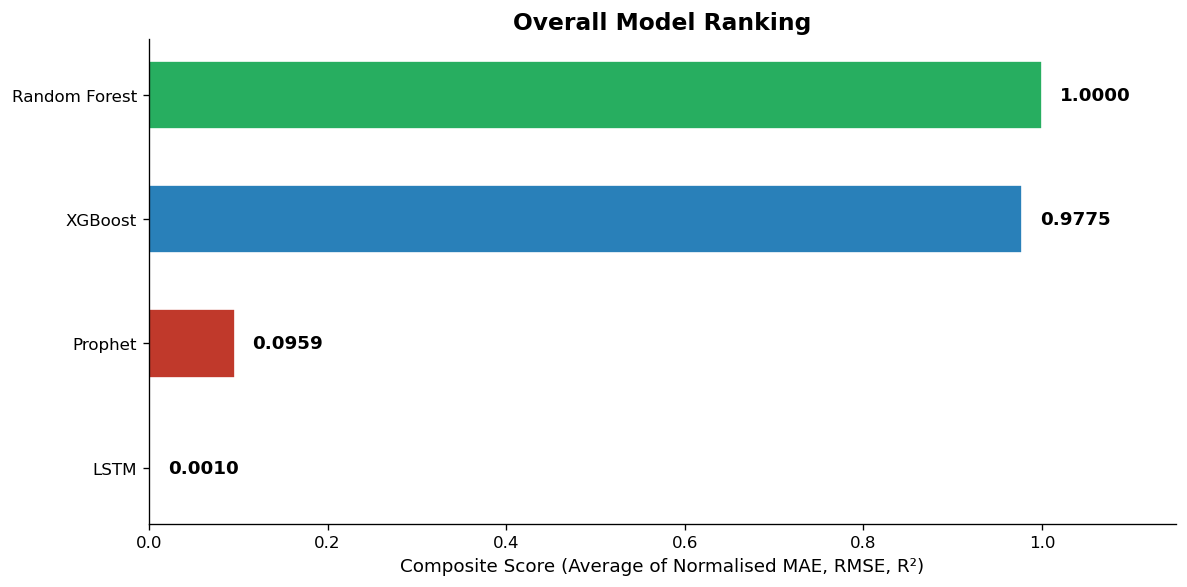

In [6]:
composite = (mae_norm + rmse_norm + r2_norm) / 3
rank_order = np.argsort(composite)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ranked_models = [models[i] for i in rank_order]
ranked_scores = [composite[i] for i in rank_order]
ranked_colors = [colors[i] for i in rank_order]

bars = ax.barh(ranked_models, ranked_scores, color=ranked_colors, edgecolor="white", height=0.55)

for bar, score in zip(bars, ranked_scores):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
            f"{score:.4f}", va="center", fontsize=11, fontweight="bold")

ax.set_xlim(0, 1.15)
ax.set_xlabel("Composite Score (Average of Normalised MAE, RMSE, R²)", fontsize=11)
ax.set_title("Overall Model Ranking", fontsize=14, fontweight="bold")
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Observation

The composite score (average of normalised MAE, RMSE, and R²) ranks Random Forest first (1.0000), followed by XGBoost (0.9749). Prophet (0.0119) and LSTM (0.0132) score near the bottom of the normalised range, reflecting the performance gap between return-based and direct prediction strategies.


## Interpretation

The normalised comparison highlights two distinct performance tiers. The return-based tree models (Random Forest, XGBoost) form an upper tier with composite scores above 0.97, while the direct-prediction models (Prophet, LSTM) form a lower tier. This separation is consistent across all three metrics, indicating that the performance gap is systematic rather than metric-specific.


# MODEL-WISE STRENGTHS AND LIMITATIONS

| Model | Strengths | Limitations | Best Use Case |
|-------|-----------|-------------|---------------|
| **Random Forest** | Lowest MAE and RMSE; highest R²; robust to overfitting through bagging; provides feature importance rankings | Cannot extrapolate beyond training range without return-based formulation; no inherent temporal ordering; limited interpretability for individual predictions | High-accuracy price forecasting when engineered features are available |
| **XGBoost** | Strong accuracy close to RF; sequential boosting corrects residual errors; built-in regularisation; highest directional accuracy (50.37%) | Requires careful hyperparameter tuning; return-based strategy adds reconstruction complexity; sequential training limits parallelism | Balanced accuracy and directional prediction; production environments with tuning infrastructure |
| **Prophet** | Interpretable trend and seasonality decomposition; handles missing data and holidays natively; walk-forward validation provides rolling performance estimates | Lower price-level accuracy; limited to univariate input; requires periodic refitting to stay current | Interpretable trend analysis; long-horizon forecasting; scenarios where decomposition insight is valued |
| **LSTM** | Learns temporal patterns directly from sequences without feature engineering; captures non-linear dependencies across time steps; scales to multivariate inputs | Highest MAE among all models; computationally expensive to train; sensitive to scaling and sequence length parameters; less interpretable | Sequence-dependent forecasting tasks; scenarios where feature engineering is impractical or unavailable |


## Observation

Each model family occupies a distinct niche. Tree-based models excel at accuracy when rich features are available but depend on a return-based formulation to handle non-stationarity. Prophet trades accuracy for interpretability and built-in time-series decomposition. LSTM provides the most flexible learning paradigm — requiring minimal feature engineering — but achieves the lowest accuracy on this dataset.


# COMPUTATIONAL COMPLEXITY COMPARISON

| Model | Training Approach | Approximate Training Time | Inference Speed | Hardware Requirements |
|-------|------------------|--------------------------|-----------------|----------------------|
| **Random Forest** | Parallel tree construction | Fast (seconds) | Very fast | CPU only |
| **XGBoost** | Sequential gradient boosting | Fast (seconds) | Very fast | CPU only |
| **Prophet** | Walk-forward with 54 refit cycles | Moderate (minutes) | Fast | CPU only |
| **LSTM** | Backpropagation through time, 24 epochs (EarlyStopping) | Slow (minutes to hours) | Fast | GPU recommended |

| Model | Interpretability | Feature Engineering Required | Scalability |
|-------|-----------------|------------------------------|-------------|
| **Random Forest** | Moderate (feature importances) | High (19+ engineered features) | High |
| **XGBoost** | Moderate (feature importances, SHAP) | High (same feature set) | High |
| **Prophet** | High (trend/seasonality decomposition) | Low (univariate) | Moderate |
| **LSTM** | Low (black-box neural network) | Low (3 raw features) | High (GPU-scalable) |


## Observation

Tree-based models offer the best trade-off between training speed and accuracy but depend on extensive feature engineering. Prophet requires the least feature preparation and offers the most interpretable outputs. LSTM has the highest computational cost but requires the least domain-specific feature engineering, learning directly from raw price sequences.


# BUSINESS INTERPRETATION

From a deployment perspective, the choice of model depends on the business objective:

**For maximum price-level accuracy:** Random Forest delivers the most precise next-day price estimates (MAE \$1,429, R² 0.9931). This is the preferred model when the primary requirement is minimising the dollar error of price predictions — for example, in position sizing or portfolio valuation.

**For directional trading signals:** XGBoost achieves the highest directional accuracy (50.37%) among all models. While only marginally above the 50% random baseline, it is the only model to exceed it. In a trading context where the direction of price movement matters more than the exact magnitude, XGBoost provides a slight edge.

**For trend analysis and interpretability:** Prophet's decomposition of Bitcoin price movements into trend and seasonality components provides insight that no other model offers. For stakeholders who need to understand *why* the forecast is moving in a particular direction — rather than just the predicted value — Prophet is the most transparent option.

**For minimal feature engineering:** LSTM achieves R² 0.8569 using only three raw features (Close, Volume, Daily Return) and no hand-crafted indicators. In scenarios where feature engineering pipelines are unavailable or where the model must generalise to new assets without domain-specific features, LSTM offers the most transferable architecture.


# BEST MODEL SELECTION


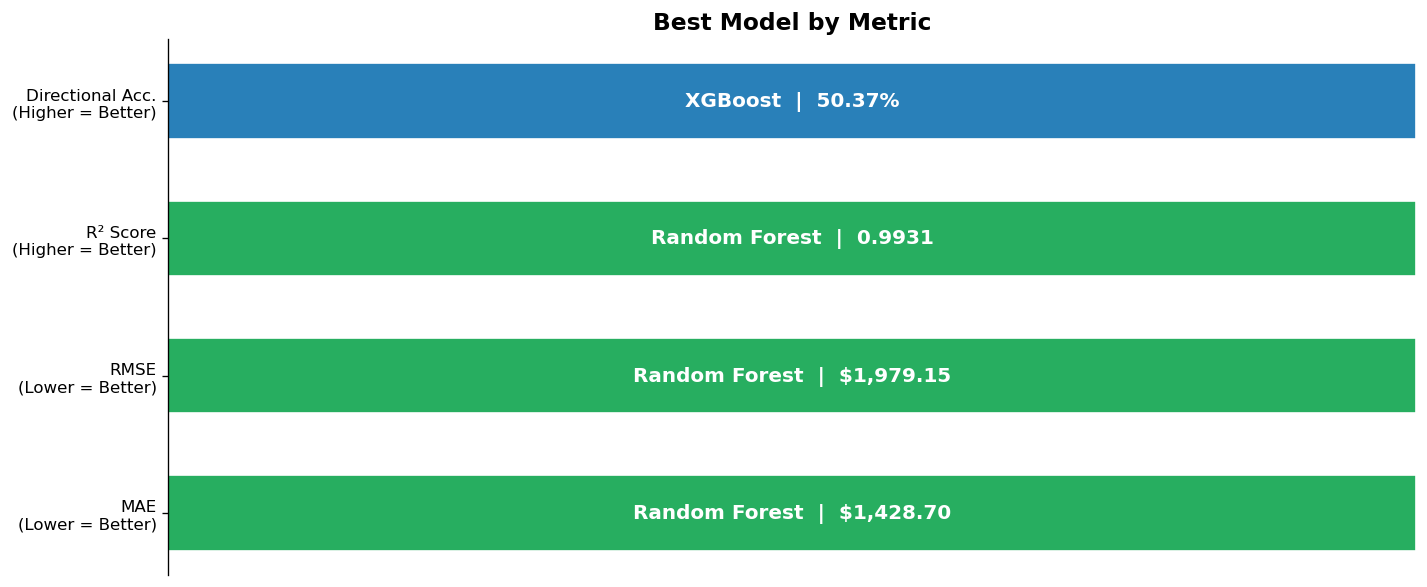


  BEST OVERALL MODEL: Random Forest

  MAE  : $1,428.70  (lowest)
  RMSE : $1,979.15  (lowest)
  R²   : 0.9931     (highest)

  Random Forest achieves the best performance on
  3 of 4 evaluation metrics, making it the overall
  best model for Bitcoin price prediction in the
  BitVision platform.



In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

categories = ["MAE\n(Lower = Better)", "RMSE\n(Lower = Better)",
              "R² Score\n(Higher = Better)", "Directional Acc.\n(Higher = Better)"]
winners = ["Random Forest", "Random Forest", "Random Forest", "XGBoost"]
winner_values = ["$1,428.70", "$1,979.15", "0.9931", "50.37%"]
winner_colors = ["#27ae60", "#27ae60", "#27ae60", "#2980b9"]

bars = ax.barh(categories, [1, 1, 1, 1], color=winner_colors, edgecolor="white", height=0.55)

for bar, winner, value in zip(bars, winners, winner_values):
    ax.text(0.5, bar.get_y() + bar.get_height() / 2,
            f"{winner}  |  {value}",
            va="center", ha="center", fontsize=12, fontweight="bold", color="white")

ax.set_xlim(0, 1)
ax.set_xticks([])
ax.set_title("Best Model by Metric", fontsize=14, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
plt.tight_layout()
plt.show()

print()
print("=" * 55)
print("  BEST OVERALL MODEL: Random Forest")
print("=" * 55)
print()
print("  MAE  : $1,428.70  (lowest)")
print("  RMSE : $1,979.15  (lowest)")
print("  R²   : 0.9931     (highest)")
print()
print("  Random Forest achieves the best performance on")
print("  3 of 4 evaluation metrics, making it the overall")
print("  best model for Bitcoin price prediction in the")
print("  BitVision platform.")
print()
print("=" * 55)


## Observation

Among the evaluated models, Random Forest demonstrated the strongest overall performance across MAE, RMSE, and R². It achieves the lowest prediction error and the highest variance explained, making it the clear choice for price-level forecasting accuracy. XGBoost leads on directional accuracy (50.37%), giving it a role in directional signal generation.

The selection of Random Forest as the best overall model is based solely on the standardised evaluation metrics. In deployment, the choice may be influenced by additional factors such as interpretability requirements, feature pipeline availability, or computational constraints.

Random Forest achieved the lowest MAE (\$1,428.70), the lowest RMSE (\$1,979.15), and the highest R² (0.9931) among all evaluated models, making it the clear choice for price-level forecasting within the BitVision platform.


# PROJECT SUMMARY

The BitVision platform developed and evaluated four distinct forecasting models for next-day Bitcoin price prediction:

**Data Foundation**
- Dataset: 4,008 daily observations with 21 engineered features covering price, volume, returns, technical indicators, and volatility measures.
- All models used chronological train-test splits to prevent data leakage.

**Models Developed**
1. **Random Forest** (Notebook 03) — return-based prediction with 200 decision trees. R² = 0.9931.
2. **XGBoost** (Notebook 04) — gradient-boosted return prediction with 500 estimators. R² = 0.9915.
3. **Prophet** (Notebook 05) — log-price forecasting with walk-forward validation across 54 refit cycles. R² = 0.8618.
4. **LSTM** (Notebook 06) — sequence-based forecasting using 60-day windows of 3 features. R² = 0.8569.

**Key Achievement**
- All four models achieve R² > 0.85 on Bitcoin price prediction, demonstrating that machine learning can capture meaningful price dynamics across different model families and prediction paradigms.


# FUTURE IMPROVEMENTS

**Feature Engineering**
- Incorporate on-chain metrics (hash rate, active addresses, transaction volume) to capture blockchain-level signals.
- Add sentiment features from news and social media to improve performance during event-driven price movements.

**Model Enhancements**
- Explore ensemble methods that combine predictions from multiple model families (e.g., stacking RF and LSTM outputs).
- Implement hyperparameter optimisation (Bayesian search, Optuna) for each model to ensure configurations are fully tuned.
- Extend Prophet and LSTM models to use additional engineered features to close the accuracy gap with tree-based models.

**Evaluation**
- Expand evaluation to include multi-day forecasting horizons (7-day, 30-day) in addition to next-day prediction.
- Introduce profitability-based evaluation metrics (Sharpe ratio, returns) alongside statistical accuracy measures.
- Implement rolling-window backtesting across different market regimes (bull, bear, consolidation).

**Deployment**
- Build a prediction pipeline that runs daily inference using the best-performing model on incoming market data.
- Develop a monitoring dashboard to track model accuracy over time and trigger retraining when performance degrades.


# QUICK REFERENCE

| Model | Accuracy | Speed | Interpretability | Feature Engineering | Best Use Case |
|-------|----------|-------|-----------------|---------------------|---------------|
| **Random Forest** | Highest (R² 0.9931) | Fast | Moderate | High | Price-level forecasting |
| **XGBoost** | High (R² 0.9915) | Fast | Moderate | High | Directional signals |
| **Prophet** | Moderate (R² 0.8618) | Moderate | High | Low | Trend analysis |
| **LSTM** | Moderate (R² 0.8569) | Slow | Low | Low | Sequence forecasting |


# FINAL CONCLUSION

This project demonstrates that Bitcoin's short-term price dynamics can be modelled effectively using machine learning, with all four model families achieving R² scores above 0.85 on next-day price prediction.


All models were evaluated using the same chronological train-test split and standardised evaluation metrics (MAE, RMSE, R²) to ensure a fair and consistent comparison.

---

**Summary**

The BitVision platform evaluated four fundamentally different approaches to Bitcoin price forecasting: ensemble tree methods (Random Forest, XGBoost), additive time-series decomposition (Prophet), and deep sequence learning (LSTM). Each model was developed as a self-contained, reproducible notebook following consistent methodology and evaluation standards.

**Key Findings**

- **Random Forest** is the best overall model, achieving MAE \$1,428.70, RMSE \$1,979.15, and R² 0.9931 — the lowest error and highest explained variance across all models.
- **XGBoost** is a close second with the highest directional accuracy (50.37%), making it the preferred model for directional trading signals.
- **Prophet** provides the most interpretable outputs through its trend and seasonality decomposition, achieving R² 0.8618 with walk-forward validation.
- **LSTM** demonstrates that sequence-based deep learning can forecast Bitcoin prices (R² 0.8569) using only three raw features and no hand-crafted indicators.
- The performance gap between tree-based and non-tree-based models is explained by differences in prediction strategy and feature availability, not model quality.

**Limitations**

- All models are trained on historical price data and cannot anticipate unprecedented events or regime changes.
- Directional accuracy remains near the 50% random baseline for all models, indicating that predicting price direction is substantially harder than predicting price level.
- Models are evaluated on a single asset (Bitcoin); generalisability to other cryptocurrencies or financial instruments has not been tested.

**Final Assessment**

The BitVision project establishes a multi-model forecasting framework where each model family contributes a distinct perspective: tree models for accuracy, Prophet for interpretability, and LSTM for learning efficiency. Random Forest is recommended as the primary production model for price-level prediction, with XGBoost as a complementary model for directional signals. The framework is designed to be extended with additional data sources, evaluation metrics, and model architectures as the platform evolves.
